### Importing Packages

In [146]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm 

import scipy
from scipy.optimize import linear_sum_assignment

import copy

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from functools import partial

### Seed

In [10]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing Data

In [11]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Helper Functions

In [15]:
def filter_data(dataset, allowed_digits):

    """
    The function filter_data generates a subset of the given MNIST dataset consisting of all and only all of
    the images of digits in allowed_digits

    Args:
        dataset: MNIST dataset 
        allowed_digits: list of digits to look for in dataset

    Returns:
        filtered_dataset: MNIST subset of dataset consisting of all and only all digits in allowed_digits
    """

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

In [50]:
def train_model(model, training_data_loader, testing_data_loader, 
                training_digit_group, num_epochs, 
                penalty_function=None, λ=1,
               ):

    """
    The function train_model trains the given model on the given MNIST digits, using the given relevant 
    subset of the MNIST dataset, for the given number of epochs. At the end of every epoch 1) the model is 
    tested on the entire MNIST testing dataset and a confusion matrix is developed, and 2) the hidden
    representation of the all digits the model was trained on (the 64-dimensional output vector of the last
    hidden layer in the neural network) is retrieved, and the given number of principal components are computed.

    Args:
        model: the neural network you wish to train
        training_data_loader: DataLoader of the subset of the MNIST training dataset corresponding to training_digit_group
        testing_data_loader: List of DataLoaders of the properly sorted MNIST testing dataset
        training_digit_group: list of digits you wish to train the model on
        num_epochs: positive integer number of tiems you wish for the model to be trained on training_data_loader
        old_pca_componetns: array of old pca components you are use to constrain learning
        λ: float, inverse plasticity hyperparameter

    Returns:
        model: trained neural network
        cm_epoch_set: list of confusion matrices computed after each epoch of training
        pca_epoch_set: list of PCAs computed after each epoch of training
        scaler_epoch_set: list of scalers cfit after each epoch after training
    """

    base_loss_function = nn.CrossEntropyLoss()

    if penalty_function is None:
        penalty_function = null_penalty
        
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    cm_epoch_set = []
    pca_epoch_set = []
    scaler_epoch_set = []

    for epoch in tqdm(range(num_epochs)):

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0
        
        for inputs, labels in training_data_loader:

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = base_loss_function(outputs, labels) + λ*penalty_function(model, inputs)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Total Training Loss: {total_loss:.4f}")

        ############################
        #### VALIDATING
        ############################

        model.eval()

        with torch.no_grad():
            
            cm = get_cm(model, testing_data_loader)
            pca, scaler = get_pca(model, testing_data_loader, training_digit_group)

            cm_epoch_set.append(cm)
            pca_epoch_set.append(pca)
            scaler_epoch_set.append(scaler)

    return model, cm_epoch_set, pca_epoch_set, scaler_epoch_set

### get_cm(model, testing_data_loader)

Builds a confusion matrix for the given model using the testing data from testing_data_loader. Predictions are made by taken as the highest probability logit in the output of the mode:

$$prediction = \underset{i\in[0, 9]}{max}\hspace{0.1cm}l_{i}$$

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}labels \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{1,2} & \cdots & n_{1, 10} \\
n_{2,1} & n_{2,2} & \cdots & n_{2, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{10,1} & n_{10,2} & \cdots & n_{10, 10}\end{bmatrix}}$$

    Args:
        model                : neural network type; trained neural network
        testing_data_loader  : list type; list of DataLoaders of properly sorted MNIST testing images

    Returns:
        cm                   : array type; confusion matrix visualizing how the model predicts (rows) images of a specific true label (columns)

In [18]:
def get_cm(model, testing_data_loader):

    cm = np.zeros((10, 10))

    for true_label in range(10):

        for inputs, labels in testing_data_loader[true_label]:

            outputs = model(inputs)

            predicted_labels = torch.argmax(outputs, dim=1).numpy()

            np.add.at(cm, (predicted_labels, true_label), 1)

    return cm

### get_pca(model, testing_data_loader, digit_group)

Performs a principal component analysis (PCA) on the hidden-state representation of a group of digits digit_group within the neural network model. PCA is done by computing eigenvalue-eigenvector pairs of the Pearson-correlation matrix (covariance matrix is computed as feature covariances of feature-standardized data):

$$ \{\lambda_i, \hat{u}_i\}: \hspace{1cm} \mathbf{C}\hat{u}=\lambda_i\hat{u}_i$$

$$\underset{num \hspace{0.1cm}features\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{C}}=\frac{1}{num\hspace{0.1cm}samples-1}\underset{num\hspace{0.1cm}features\hspace{0.1cm}\times batch\hspace{0.1cm}size}{\mathbf{Z}^T}\hspace{0.3cm}\underset{batch \hspace{0.1cm}size\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{Z}}$$

    Args:
        model: neural network type; the neural network whose hidden representation we are probing
        testing_data_loader: DataLoader type; the properly sorted testing data used to evaluate model
        digit_group: list type; list of digits we are probing for the hidden representation of

    Returns:
        pca: pca type; pca fit to the standardized hidden representation data
        scaler: ? type; scaler used to fit the pca 

In [19]:
def get_pca(model, testing_data_loader, digit_group):
    
    all_batches = []                                             # shape: null
 
    for digit in digit_group:
        
        for inputs, labels in testing_data_loader[digit]:
            
            hidden_outputs = model.hidden(inputs).numpy()        # shape: (batch_size, hidden_size)
       
            all_batches.append(hidden_outputs)                   
 
    data = np.concatenate(all_batches, axis=0)                   # shape: (num_batchs X batch_size, hidden_size)
 
    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(data)
 
    pca = PCA()
    pca.fit(standardized_data)                                   # shape: (hidden_size, hidden_size) (since hidden_size < num_batchs X batch_size)
 
    return pca, scaler

### pca_drift_penalty(model, old_pca_components, inputs)

This function penalizes how much of the current hidden representation of the inputs lies within the span of some subset of the old principal components. The penalty is computed according to the following rule:


$$\underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i} = \underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}\hspace{0.3cm}\underset{(hidden\hspace{0.1cm} size \hspace{0.1cm}\times\hspace{0.1cm} pca\hspace{0.1cm} size)}{\mathbf{P^T}}\hspace{0.3cm}\underset{(pca\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{P}}$$

$$\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{R}_i} = \underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}-\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i}$$

$$\underset{1\times 1}{penalty} = \frac{1}{batch\hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm}
hidden\hspace{0.1cm}size}\sum_{n=1}^{batch\hspace{0.1cm} size}\sum_{m=1}^{hidden\hspace{0.1cm} size}R_{nm}^2$$

    Args:
        model                      : Neural Network type; neural network being trained
        inputs                     : tensor type; input data the neural network is being trained on
        old_pca_components         : array type; subspace the hidden representation will be projected onto and reconstructed from

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training
        

In [49]:
def pca_drift_penalty(model, inputs, old_pca_components):

    if old_pca_components is None:
        return torch.tensor(0.0)
    
    V = torch.tensor(
        old_pca_components,                            # shape: (pca_size, hidden_size)
        dtype=torch.float32
    )

    hidden_outputs = model.hidden(inputs)              # shape: (batch_size, hidden_size)

    projections   = hidden_outputs @ V.T               # shape: (batch_size, hidden_size) X (hidden_size, pca_size) = (batch_size, pca_size)
    reconstructions = projections @ V                  # shape: (batch_size, pca_size) X (pca_size, hidden_size) = (batch_size, hidden_size)

    residual = hidden_outputs - reconstructions        # shape: (batch, hidden_size)
    penalty  = torch.mean(residual ** 2)               # shape: ()

    return penalty

In [147]:
def corrs_penalty(model, inputs, cluster_labels, cluster_corrs, old_model):

    
    old_L1W = old_model.layer1.weight.detach()
    old_L1B = old_model.layer1.bias.detach().unsqueeze(1)
    old_L1P = torch.cat((old_L1W, old_L1B), dim=1)

    old_L2W = old_model.layer2.weight.detach()
    old_L2B = old_model.layer2.bias.detach().unsqueeze(1)
    old_L2P = torch.cat((old_L2W, old_L2B), dim=1)
    
    old_L3W = old_model.layer3.weight.detach()
    old_L3B = old_model.layer3.bias.detach().unsqueeze(1)
    old_L3P = torch.cat((old_L3W, old_L3B), dim=1)

    old_params = []

    for neuron in range(old_L1P.shape[0]):
        old_params.append(old_L1P[neuron, :])

    for neuron in range(old_L2P.shape[0]):
        old_params.append(old_L2P[neuron, :])

    for neuron in range(old_L3P.shape[0]):
        old_params.append(old_L3P[neuron, :])
    

    L1W = model.layer1.weight
    L1B = model.layer1.bias.unsqueeze(1)
    L1P = torch.cat((L1W, L1B), dim=1)

    L2W = model.layer2.weight
    L2B = model.layer2.bias.unsqueeze(1)
    L2P = torch.cat((L2W, L2B), dim=1)

    L3W = model.layer3.weight
    L3B = model.layer3.bias.unsqueeze(1)
    L3P = torch.cat((L3W, L3B), dim=1)

    params = []

    for neuron in range(L1P.shape[0]):
        params.append(L1P[neuron, :])

    for neuron in range(L2P.shape[0]):
        params.append(L2P[neuron, :])

    for neuron in range(L3P.shape[0]):
        params.append(L3P[neuron, :])
        

    penalty = torch.tensor(0.0)

    num_neurons = len(params)

    for neuron in range(num_neurons):

        cluster_id = cluster_labels[neuron]

        corr = torch.tensor(cluster_corrs[cluster_id-1])

        penalty = penalty + corr*torch.linalg.vector_norm(params[neuron]-old_params[neuron])**2

    return penalty

In [63]:
def null_penalty(model, inputs):
    return torch.tensor(0.0)

### monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42)

Monte Carlo estimate (N = n_samples, from seed) of the mean and standard deviation of the cross-Gram-matrices two randomly sampled dim_subspace-dimensional orthonormal bases $\mathcal{U}, \mathcal{V}\in\mathbb{R}^{dim\hspace{0.1cm}space \hspace{0.1cm}\times\hspace{0.1cm} dim \hspace{0.1cm} subspace}$. The n_samples pairs of subspaces are drawn as a dim_space by dim_subspace array of dim_subspace samples from the dim_space dimensional standard normal distribution, $\mathcal{N}_{dim\hspace{0.1cm}space}(0, 1)$ and orthonormalized. 

Analytical Expressions (dim_subspace=1):

$$\mu_{|\hat{u}\cdot\hat{v}|} = \frac{\Gamma\left(\frac{d}{2}\right)}{\sqrt{\pi}\Gamma\left(\frac{d+1}{2}\right)}\overset{d=64}{\approx}0.100$$

$$\sigma_{|\hat{u}\cdot\hat{v}|} = \sqrt{\frac{1}{d}-\mu_{|\hat{u}\cdot\hat{v}|}^2}\overset{d=64}{\approx}0.075$$

    Args:
        dim_subspace          : int type; dimensionality of subspaces being drawn
        dim_space             : int type; dimensionality of the overall space embedding the subspaces
        n_samples             : int type; number of sample drawn for the Monte Carlo approximation
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        μ                     : float type; sample mean computed by Monte Carlo
        σ                     : float type; sample standard deviation computed by Monte Carlo

In [24]:
def monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42):

    rng = np.random.default_rng(seed)
 
    U = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)
    V = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)

    U, _ = np.linalg.qr(U)                                                   # shape: (n_samples, dim_space, dim_subspace)
    V, _ = np.linalg.qr(V)                                                   # shape: (n_samples, dim_space, dim_subspace)

    cgm = np.abs(np.einsum("ndi, ndj -> nij", U, V))                             # shape: (n_samples, dim_subspace, dim_subspace)

 
    μ = np.mean(cgm)                      # shape: ()
    σ = np.std(cgm)                       # shape: ()  
 
    return μ, σ

In [25]:
def get_hungarian(benefit_matrix):

    tol = 1e-10

    # Normalize benefit matrix to [0,1]
    benefit_matrix = np.clip(benefit_matrix, 0, 1)

    # Convert trace maximization into trace minimization
    cost_matrix = 1 - benefit_matrix

    n, m = cost_matrix.shape

    cost_matrix -= cost_matrix.min(axis=0, keepdims=True)
    cost_matrix -= cost_matrix.min(axis=1, keepdims=True)

    # Starring 0s
    stars_matrix = np.zeros_like(cost_matrix, dtype=bool)

    row_has_star = np.zeros(n, dtype=bool)
    col_has_star = np.zeros(m, dtype=bool)

    # Choosing sequentially unclaimed rows or columns with 0s
    for i in range(n):

        for j in range(m):

            if cost_matrix[i,j] <= tol and not row_has_star[i] and not col_has_star[j]:

                stars_matrix[i,j] = 1
                row_has_star[i] = 1
                col_has_star[j] = 1

    # Main loop

    # Outer Loop
    while True:

        row_covered = np.zeros(n, dtype=bool)
        col_covered = np.zeros(m, dtype=bool)
        primes_matrix = np.zeros_like(cost_matrix, dtype=bool)

        for j in range(m):

            for i in range(n):

                col_covered[j] |= stars_matrix[i][j] 

        if col_covered == np.ones(m, dtype=bool):

            break 

        # Inner Loop
        while True:

            for r in range(n):

                for c in range(m):

                    if cost_matrix[r,c] < tol and not row_covered[r] and not col_covered[c]:

                        primes_matrix[r, c] = 1

                        # Outcome B
                        for c_star in range(m):

                            if stars_matrix[r, c_star]:

                                row_covered[r] = 1
                                col_covered[c_star] = 0
                                break
                                
                            




                    
            

In [26]:
def compute_random_baseline_gdist(dim_space, dim_subspace, n_samples=100_000, seed=42):

    rng = np.random.default_rng(seed)

    # Sample uniformly on the hypersphere via normalised Gaussians
    U = rng.standard_normal((n_samples, dim_space, dim_subspace)) 
    V = rng.standard_normal((n_samples, dim_space, dim_subspace))
    
    U, _ = np.linalg.qr(U) #(n_samples, dim_space, dim_subspace)
    V, _ = np.linalg.qr(V) #(n_samples, dim_space, dim_subspace)
    
    M = np.einsum("nij, nik->njk", U, V)
    sigma = np.linalg.svd(M, compute_uv=False)
    sigma = np.clip(sigma, -1, 1)

    pangles = np.arccos(sigma)

    gdist = np.linalg.norm(pangles, axis=1)

    return gdist.mean(axis=0), gdist.std(axis=0)

### get_all_activation(model, testing_data_loader, digit_group)

This function gets the activations of all hidden layers of the given model when seeing images of the given digit group from the given testing data loader. 

    Args:
        model: neural network type; the model we are gather all layer activations from
        testing_data_loader: list type; list of DataLoader types of MNIST testing images sorted by digit
        digit_group: list type; list of digits input into the network generating activations

    Returns:
        all_activations: array type; array of all activations of shape (num_batches X batch_size, num_neurons_tot) 
        all_labels: array type; array of all labels of inputs into the model



In [27]:
def get_all_activations(model, testing_data_loader, digit_group):

    all_a1, all_a2, all_a3, all_labels = [], [], [], []

    model.eval()

    with torch.no_grad():
    
        for digit in digit_group:

            for inputs, labels in testing_data_loader[digit]:

                a1 = model.forward1(inputs).numpy()             # shape: (batch_size, num_neurons_1)
                a2 = model.forward2(inputs).numpy()             # shape: (batch_size, num_neurons_2) 
                a3 = model.forward3(inputs).numpy()             # shape: (batch_size, num_neurons_3)

                all_a1.append(a1)                               # shape: (num_batches, batch_size, num_neurons_1)
                all_a2.append(a2)                               # shape: (num_batches, batch_size, num_neurons_2)
                all_a3.append(a3)                               # shape: (num_batches, batch_size, num_neurons_3)
                all_labels.append(labels.numpy())               # shape: (num_batches, batch_size)


        all_a1 = np.concatenate(all_a1, axis=0)                 # shape: (num_batches X batch_size, num_neurons_1)
        all_a2 = np.concatenate(all_a2, axis=0)                 # shape: (num_batches X batch_size, num_neurons_2)
        all_a3 = np.concatenate(all_a3, axis=0)                 # shape: (num_batches X batch_size, num_neurons_3)
        all_labels = np.concatenate(all_labels, axis=0)         # shape: (num_batches X batch_size)

        all_activations = np.concatenate((all_a1, all_a2, all_a3), axis=1) # shape: (num_batches X batch_size, num_neurons_tot)

    return all_activations, all_labels

### get_correlation(activations)

Returns the Pearson correlation matrix of the array of all activations.

$$\underset{num\hspace{0.1cm}samples\times \hspace{0.1cm} num\hspace{0.1cm}features}{\mathbf{Z}_{ij}}=\frac{\underset{nsamples\times nvariables}{\mathbf{X}_{ij}}-\underset{nsamples\times nvariables}{\bar{\mathbf{X}}_{:,j}}}{\sigma_j}$$

$$\underset{num \hspace{0.1cm}features\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{P}}=\frac{1}{num\hspace{0.1cm}samples-1}\underset{num\hspace{0.1cm}features\hspace{0.1cm}\times num\hspace{0.1cm}samples}{\mathbf{Z}^T}\hspace{0.3cm}\underset{num\hspace{0.1cm}samples\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{Z}}$$

$$\forall i,j \hspace{0.5cm} P_{ij}\in[-1, 1]$$

    Args:
        activations: array type; array of all sample of neuron activations of all layers

    Returns:
        corr_matrix: array type; Pearson correlation matrix
    

In [28]:
def get_correlation(activations):

    corr_matrix = np.corrcoef(activations.T)                # shape: (num_neurons_tot, num_neurons_tot)

    np.nan_to_num(corr_matrix, nan=0.0, copy=False)         # shape: (num_neurons_tot, num_neurons_tot)

    return corr_matrix                                      # shape: (num_neurons_tot, num_neurons_tot)

### get_cluster(corr_matrix, corr_threshold)

Performs agglomerative clustering on neurons using $1-|P_{ij}|$ as the distance between neurons $i$ and $j$. 

    Args:
        corr_matrix: array type; Pearson correlation matrix of neuron activations
        corr_threshold: float type; the minimum necessary absolute Pearson correlation for two neurons to be merged

    Returns:
        cluster_labels: array type; cluster IDs of all neurons in neural network

In [29]:
def get_cluster(corr_matrix, corr_threshold=0.9):

    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, copy=False)          # shape: (num_neurons_tot, num_neurons_tot)

    dist = 1 - np.clip(np.abs(corr_matrix), 0, 1)                          # shape: (num_neurons_tot, num_neurons_tot)
    np.fill_diagonal(dist, 0)                                              # shape: (num_neurons_tot, num_neurons_tot)

    condensed = squareform(dist, checks=False)                             # shape: (num_neurons_tot X (num_neurons_tot-1)/2, )

    Z = linkage(condensed, method="average")                               
    cluster_labels = fcluster(Z, t=1-corr_threshold, criterion="distance")        # shape: (num_neurons_tot, )

    return cluster_labels                                                  # shape: (num_neurons_tot, )

In [30]:
def get_cluster_digit_correlation(cluster_labels, digit_group, all_activations, all_labels):

    corrs_cluster_set = []                                                                # shape: (num_clusters)

    num_clusters = np.max(cluster_labels)

    for cluster_id in range(1, num_clusters+1):

        corrs_digit_set = []                                                               # shape: (num_digits, )

        cluster_mask_bool = cluster_labels == cluster_id                                   # shape: (num_neurons_tot, ) bool

        coarse_cluster_activations = all_activations[:, cluster_mask_bool].mean(axis=1)    # shape: (num_samples, )

        for digit in digit_group:

            binary_label_mask = np.where(all_labels==digit, 1, 0)                          # shape: (num_samples, ) binary

            corr = np.corrcoef(coarse_cluster_activations, binary_label_mask)[0, 1]        # shape: ()

            corr = np.nan_to_num(corr, nan=0.0)

            corrs_digit_set.append(corr)

        corrs_cluster_set.append( np.max( np.abs(corrs_digit_set) ) )

    return np.array(corrs_cluster_set)                                                     # shape: (num_clusters)

In [31]:
def plot_cms(cm_set):

    num_groups, num_epochs = len(cm_set), len(cm_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )

    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = cm_set[m][n]

            im = ax.imshow(cm, cmap='Blues')

            # annotate cells
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(
                        j, i,
                        str(int(cm[i, j])),
                        ha='center',
                        va='center',
                        color='black',
                        fontsize=8
                    )

            ax.set_title(f"Training Group {m+1}, Epoch {n+1}")

            ax.set_xlabel("True Label")
            ax.set_ylabel("Predicted Label")

    # One shared colorbar (important)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

    plt.show()

    return

In [17]:
def make_cgm_colormap(vmin=-2, vmax=12, neutral_low=0, neutral_high=3):
    """
    Three-zone colormap for standardised CGM z-scores.
 
    Zone 1  [vmin,         neutral_low)   cool blue gradient
                Overlap is *below* the random mean — the PC pair is more
                orthogonal than two random unit vectors would be on average.
                Note: the physical minimum is z ≈ -1.33  (when |u·v| = 0),
                so the deep blue end of this zone is unreachable.
 
    Zone 2  [neutral_low,  neutral_high]  flat grey
                Overlap is statistically indistinguishable from chance.
                The flat colour makes the noise band immediately obvious
                regardless of the value within it.
 
    Zone 3  (neutral_high, vmax]          warm gradient (yellow → red)
                Overlap significantly exceeds the random baseline —
                evidence of genuine shared structure between the two PCAs.
 
    The hard colour breaks at neutral_low and neutral_high are created by
    repeating each boundary position in the colour list with two different
    colours; LinearSegmentedColormap treats this as a step discontinuity.
 
    Args:
        vmin, vmax      : z-score range for the colour scale
        neutral_low     : lower boundary of the grey (noise) band; default 0
        neutral_high    : upper boundary of the grey (noise) band; default 3
 
    Returns:
        cmap (LinearSegmentedColormap)
        norm (Normalize)
    """
    def p(z):
        return (z - vmin) / (vmax - vmin)
 
    cmap = LinearSegmentedColormap.from_list(
        'cgm_zones',
        [
            (p(vmin),          '#2166AC'),  # deep blue  (most orthogonal)
            (p(neutral_low),   '#D1E5F0'),  # pale blue  (approaching random mean)
            (p(neutral_low),   '#B0B0B0'),  # ← hard break: grey noise band begins
            (p(neutral_high),  '#B0B0B0'),  # grey noise band ends
            (p(neutral_high),  '#FFFFCC'),  # ← hard break: warm signal zone begins
            (p(6),             '#FD8D3C'),  # orange
            (p(9),             '#D7191C'),  # red
            (p(vmax),          '#67000D'),  # dark red   (strongest alignment)
        ],
        N=512
    )
 
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
 
    return cmap, norm

In [143]:
def plot_cgms(pca_set, μ_cgm, σ_cgm, window=(-1, -1), diagonalize=False):

    ###########################################
    #### MAKING CGMS
    ###########################################
    
    num_groups, num_epochs = len(pca_set), len(pca_set[0])
    flattened_pca_set = np.reshape(pca_set, (-1))
    num_plots = len(flattened_pca_set)

    
    lower, upper = window
    
    if lower == -1:
        lower = 0
        
    if upper == -1:
        upper = flattened_pca_set[0].components_.shape[0]
            

    plot_set = []

    for i in range(num_plots):

        pca_components_A = flattened_pca_set[num_epochs-1].components_
        pca_components_B = flattened_pca_set[i].components_

        cgm_i = np.abs(pca_components_A @ pca_components_B.T)
        z_cgm_i = (cgm_i-μ_cgm)/σ_cgm
        wz_cgm_i = z_cgm_i[lower:upper, lower:upper]

        if diagonalize:

            cost = 1 - wz_cgm_i
            rows, cols = linear_sum_assignment(cost)
            dwz_cgm_i = wz_cgm_i[:, cols]
            plot_set.append(dwz_cgm_i)

        else:

            plot_set.append(wz_cgm_i)

    
    ###########################################
    #### MAKING PLOTS
    ###########################################

    cgm_cmap, cgm_norm = make_cgm_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4    
                                        )
 
    CGM_TICKS  = [-2, -1.3,         0,              2,        4,        6,        9,       12]
    CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4', '6', '9', '12']
    
    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )

    axes = np.array(axes).reshape(num_epochs, num_groups)

    for i in range(num_plots):

        g_earlier = i//num_epochs
        g_later = (i+1)//num_epochs
        e_earlier = i%num_epochs
        e_later = (i+1)%num_epochs

        ax = axes[e_earlier, g_earlier]

        plot_i = plot_set[i]

        im = ax.imshow(plot_i, cmap=cgm_cmap, norm=cgm_norm)

        ax.set_title(f"z-CGM of Training Group {g_earlier+1}, Epoch {e_earlier+1} \n on Training Group {0+1}, Epoch {num_epochs}")

        ax.set_xlabel(f"PCs of Training Group {g_earlier+1}, Epoch {e_earlier+1}")
        ax.set_ylabel(f"PCs of Training Group {0+1}, Epoch {num_epochs}")

    cbar = fig.colorbar(im, ax=axes, ticks=CGM_TICKS, fraction=0.02, pad=0.04)
    cbar.ax.set_yticklabels(CGM_LABELS)
    cbar.set_label("PC overlap (σ above random baseline)", rotation=270, labelpad=20)

    plt.show()
    
    return

### Training Data

In [33]:
training_digit_groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8, 9]]

In [34]:
training_groups = []

In [35]:
num_training_groups= len(training_digit_groups)

for i in range(num_training_groups):

    training_digit_group = training_digit_groups[i]

    X = filter_data(train_dataset, training_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_groups.append(Y)

### Testing Data

In [36]:
testing_digit_groups = [[i] for i in range(10)]

In [37]:
testing_groups = []

In [38]:
num_testing_groups = len(testing_digit_groups)

for i in range(num_testing_groups):

    testing_digit_group = testing_digit_groups[i]

    X = filter_data(test_dataset, testing_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_groups.append(Y)

In [39]:
for inputs, labels in training_groups[2]:
    print(inputs.shape, labels.shape)
    print(labels)
    break
for inputs, labels in testing_groups[9]:
    print(inputs.shape, labels.shape)
    print(labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([8, 6, 8, 9, 6, 6, 7, 6, 7, 8, 9, 7, 9, 7, 6, 7, 9, 7, 7, 9, 6, 9, 7, 6,
        9, 9, 8, 7, 6, 7, 6, 7, 9, 6, 6, 6, 8, 9, 7, 8, 6, 9, 9, 6, 7, 7, 8, 7,
        9, 6, 9, 8, 8, 6, 6, 7, 8, 9, 8, 7, 8, 8, 9, 6])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9])


### Data Info

In [40]:
total_num_training_images = 0
num_training_images = []

In [41]:
for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_groups[i]:

        S += len(labels)

    num_training_images.append(S)

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 18623
Number of training images in group 2: 17394
Number of training images in group 3: 23983

Total number of training images: 60000


In [42]:
total_num_testing_images = 0
num_testing_images = []

In [43]:
for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_groups[i]:

        S += len(labels)

    num_testing_images.append(S)

    print(f"Number of testing images of {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of 0: 980
Number of testing images of 1: 1135
Number of testing images of 2: 1032
Number of testing images of 3: 1010
Number of testing images of 4: 982
Number of testing images of 5: 892
Number of testing images of 6: 958
Number of testing images of 7: 1028
Number of testing images of 8: 974
Number of testing images of 9: 1009

Total number of testing images: 10000


### Defining NN Architecure

In [44]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()

        self.layer1 = nn.Linear(28*28, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)

    def forward1(self, inputs):

        X = self.flatten(inputs)
        
        X = self.layer1(X)
        X = self.relu(X)

        return X

    def forward2(self, inputs):

        X = self.forward1(inputs)

        X = self.layer2(X)
        X = self.relu(X)

        return X
        

    def forward3(self, inputs):

        X = self.forward2(inputs)

        X = self.layer3(X)

        logits = X

        return logits

    def forward(self, inputs):

        X = self.forward3(inputs)

        logits = X

        return logits


    def hidden(self, inputs):

        hidden = self.forward2(inputs)

        return hidden

### Training 

In [180]:
n_epochs = 3
num_old_pca_components = 16

In [181]:
model = NeuralNetwork()

In [182]:
model_group_set = []

cm_group_set = []

pca_group_set = []

scaler_group_set = []

In [183]:
trained_model_A, trained_cm_epoch_set_A, trained_pca_epoch_set_A, trained_scaler_epoch_set_A = train_model(model, training_data_loader=training_groups[0], 
                                                                                                           testing_data_loader=testing_groups, training_digit_group=training_digit_groups[0], 
                                                                                                           num_epochs=n_epochs, 
                                                                                                           penalty_function=None, λ=1
                                                                                                          )

pca_A = trained_pca_epoch_set_A[-1]
pca_components_A = pca_A.components_[:num_old_pca_components]

model_group_set.append(copy.deepcopy(trained_model_A))
cm_group_set.append(trained_cm_epoch_set_A)
pca_group_set.append(trained_pca_epoch_set_A)
scaler_group_set.append(trained_scaler_epoch_set_A)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1, Total Training Loss: 42.9017


 33%|███▎      | 1/3 [00:09<00:19,  9.51s/it]

Epoch 2, Total Training Loss: 9.1059


 67%|██████▋   | 2/3 [00:18<00:09,  9.47s/it]

Epoch 3, Total Training Loss: 6.2652


100%|██████████| 3/3 [00:28<00:00,  9.57s/it]


In [184]:
all_activations, all_labels = get_all_activations(model_group_set[0], testing_groups, training_digit_groups[0])
corr_matrix = get_correlation(all_activations)
cluster_labels = get_cluster(corr_matrix, corr_threshold=0.5)
cluster_corrs = get_cluster_digit_correlation(cluster_labels, training_digit_groups[0], all_activations, all_labels)
print(cluster_labels)
print()
print(cluster_corrs)

#penalty_function_B = partial(pca_drift_penalty, old_pca_components = pca_components_A)
penalty_function_B = partial(corrs_penalty, cluster_labels=cluster_labels, cluster_corrs=cluster_corrs, old_model=model_group_set[0])

[ 5  4  1  6  7  7 13  5 14  7  3  1 15 16  7  4 17  7  4  7  7 18  7  7
  5  5  5  5  7 19  5  4  5 20  5  7  7  7  5  7  7 21  7  7  5  5  5  8
  7  7  7  5  6  4  5  4 22  7  7  5  7  4  5  7  7  7  4  5 23  5 24  4
 25 26  5  5 12  4  5  7  7 27  1  7  5  7  6  5  7 28  5 29  4  7  5  4
  7  4  5  7  7  4  5 30  5 31  7  6  4  7 32  4  4  5 10  4  7  7  2  5
  5  5  7  4 33  5  7  7  5  4  7  5  7 34  4  5  5  5 35  4  7 36  4  5
  7  5  5  4 37  7  7  7 38 39  7  7  7  7 40  5 41  9  5  7  5 42  4  4
 43  4 44 45  4  7  5 46 47  7 48  5 49  5  7 50 11  5  5 51  4  4  7  7
  5  5  4  5  3  3  7  7  5  7]

[0.50327619 0.46716551 0.38947484 0.74265214 0.36786156 0.70594028
 0.63803915 0.28574033 0.05699195 0.0781388  0.03502627 0.02373759
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0

C:\Users\Tyler\anaconda3\envs\biologicalRNN\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Tyler\anaconda3\envs\biologicalRNN\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [185]:
trained_model_B, trained_cm_epoch_set_B, trained_pca_epoch_set_B, trained_scaler_epoch_set_B = train_model(model, training_data_loader=training_groups[1], 
                                                                                                           testing_data_loader=testing_groups, training_digit_group=training_digit_groups[1], 
                                                                                                           num_epochs=n_epochs, 
                                                                                                           penalty_function=penalty_function_B, λ=100
                                                                                                          )

pca_B = trained_pca_epoch_set_B[-1]
pca_components_B = pca_B.components_[:num_old_pca_components]

model_group_set.append(copy.deepcopy(trained_model_B))
cm_group_set.append(trained_cm_epoch_set_B)
pca_group_set.append(trained_pca_epoch_set_B)
scaler_group_set.append(trained_scaler_epoch_set_B)    

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1, Total Training Loss: 2501.4343


 33%|███▎      | 1/3 [00:32<01:04, 32.02s/it]

Epoch 2, Total Training Loss: 838.7978


 67%|██████▋   | 2/3 [01:03<00:31, 31.95s/it]

Epoch 3, Total Training Loss: 648.9484


100%|██████████| 3/3 [01:35<00:00, 31.97s/it]


In [186]:
all_activations, all_labels = get_all_activations(model_group_set[1], testing_groups, training_digit_groups[1])
corr_matrix = get_correlation(all_activations)
cluster_labels = get_cluster(corr_matrix, corr_threshold=0.5)
cluster_corrs = get_cluster_digit_correlation(cluster_labels, training_digit_groups[1], all_activations, all_labels)
print(cluster_labels)
print()
print(cluster_corrs)

#penalty_function_C = partial(pca_drift_penalty, old_pca_components = pca_components_B)
penalty_function_C = partial(corrs_penalty, cluster_labels=cluster_labels, cluster_corrs=cluster_corrs, old_model=model_group_set[1])

[ 8  7  9  1  9  9 17  8 18 12  9  9 19 20  9 12 21  9  7 12  5 22 12 10
  8  8 10  8 12 23 10  9 10 24  8  5  5  5 10 10 12 25 10  9  8 10  8 26
 12  5 12 10  1  7 10  7 27  5  7  8 12  7  8  9  6 12  7 10 28 10 29 11
  9 30  8 10 16 12  8 12  9 31  9  5  8  9  1  9 12 32  8 33 12  5  9  7
  5  7 10  5  5  3 10 34 14 35  5  1 12 12 36  7  7  8  2  8  9 10  9  8
  9  8 12  7 37 10 12  5  8  9 13  8 12 38  7 10  8 10 39  9  6 40  7  8
  6  4  8  6 41 12  5 12 42 43  5  8  5  8 44  7 45 46 10 12 15  8  3  9
 47  6 48 49 11 12  4 50 51 12  9  8  9  8 12 52 53 10 10 54  7  9  9  7
  8 12  9 10 12 10  9  9  9  5]

[0.15096397 0.14185574 0.26075412 0.20665461 0.30092807 0.21330589
 0.42319882 0.51283573 0.27018757 0.12198268 0.39443452 0.30078291
 0.27021156 0.45198976 0.04025447 0.02783171 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0

C:\Users\Tyler\anaconda3\envs\biologicalRNN\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Tyler\anaconda3\envs\biologicalRNN\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [187]:
trained_model_C, trained_cm_epoch_set_C, trained_pca_epoch_set_C, trained_scaler_epoch_set_C = train_model(model, training_data_loader=training_groups[2], 
                                                                                                           testing_data_loader=testing_groups, training_digit_group=training_digit_groups[2], 
                                                                                                           num_epochs=n_epochs,
                                                                                                           penalty_function=penalty_function_C, λ=100
                                                                                                          )

pca_C = trained_pca_epoch_set_C[-1]
pca_components_C = pca_C.components_[:num_old_pca_components]

model_group_set.append(copy.deepcopy(trained_model_C))
cm_group_set.append(trained_cm_epoch_set_C)
pca_group_set.append(trained_pca_epoch_set_C)
scaler_group_set.append(trained_scaler_epoch_set_C)    

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1, Total Training Loss: 1124.2951


 33%|███▎      | 1/3 [00:43<01:26, 43.28s/it]

Epoch 2, Total Training Loss: 517.6362


 67%|██████▋   | 2/3 [01:26<00:43, 43.25s/it]

Epoch 3, Total Training Loss: 310.7061


100%|██████████| 3/3 [02:10<00:00, 43.33s/it]


In [188]:
for i in range(num_training_groups):

    print(model_group_set[i] is model)

False
False
False


In [189]:
all_activations, all_labels = get_all_activations(model_group_set[2], testing_groups, training_digit_groups[2])
corr_matrix = get_correlation(all_activations)
cluster_labels = get_cluster(corr_matrix, corr_threshold=0.5)
cluster_corrs = get_cluster_digit_correlation(cluster_labels, training_digit_groups[2], all_activations, all_labels)
print(cluster_labels)
print()
print(cluster_corrs)

[10 10  6 12  5  5 21 11 22  5  5  6 23 24  5  3 25  5  3  5 14 26  5  5
 10 10  8 10  5 27  8  6  8 28 10  3 14 14  8  5  5 29  5  5 10  8 11 30
  5 14  5  8 12  3  8 10 31 14  5 10  5  3 11  5 14  5 10  8 32  8 33  3
  5 34 10  8 35  3 11  5  5  6  6 14 10  5 12  8  5 36 10 37  3 14  6 10
 14  3  8 14 14  9  8 38 16 39 14 12  5  5 40 10 10 11 20  3  5  5  6 10
  8 10  5 10  6  8  5 14  4  6 17 10  5  4  3  8 11  8 41 13 42 43 10 11
  3 19  1  3 44  3 45  5 46 47 11 13 15 13 48 10 49 50  7  5 18 11  9  6
  6  3  5 51 10  5  2 52  4  4  5 10  5  6  5 53 54  8  7 55 10  6  6  3
  4  5  6  6  6  5  6  4  4  6]

[0.20386655 0.03189821 0.49030863 0.62168625 0.37922691 0.58059108
 0.45055174 0.07007879 0.40855388 0.48502309 0.39562038 0.09081962
 0.52589157 0.19145972 0.11324549 0.2127669  0.12632923 0.24131818
 0.06624284 0.22972918 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.  

C:\Users\Tyler\anaconda3\envs\biologicalRNN\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Tyler\anaconda3\envs\biologicalRNN\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Confusion Matrix

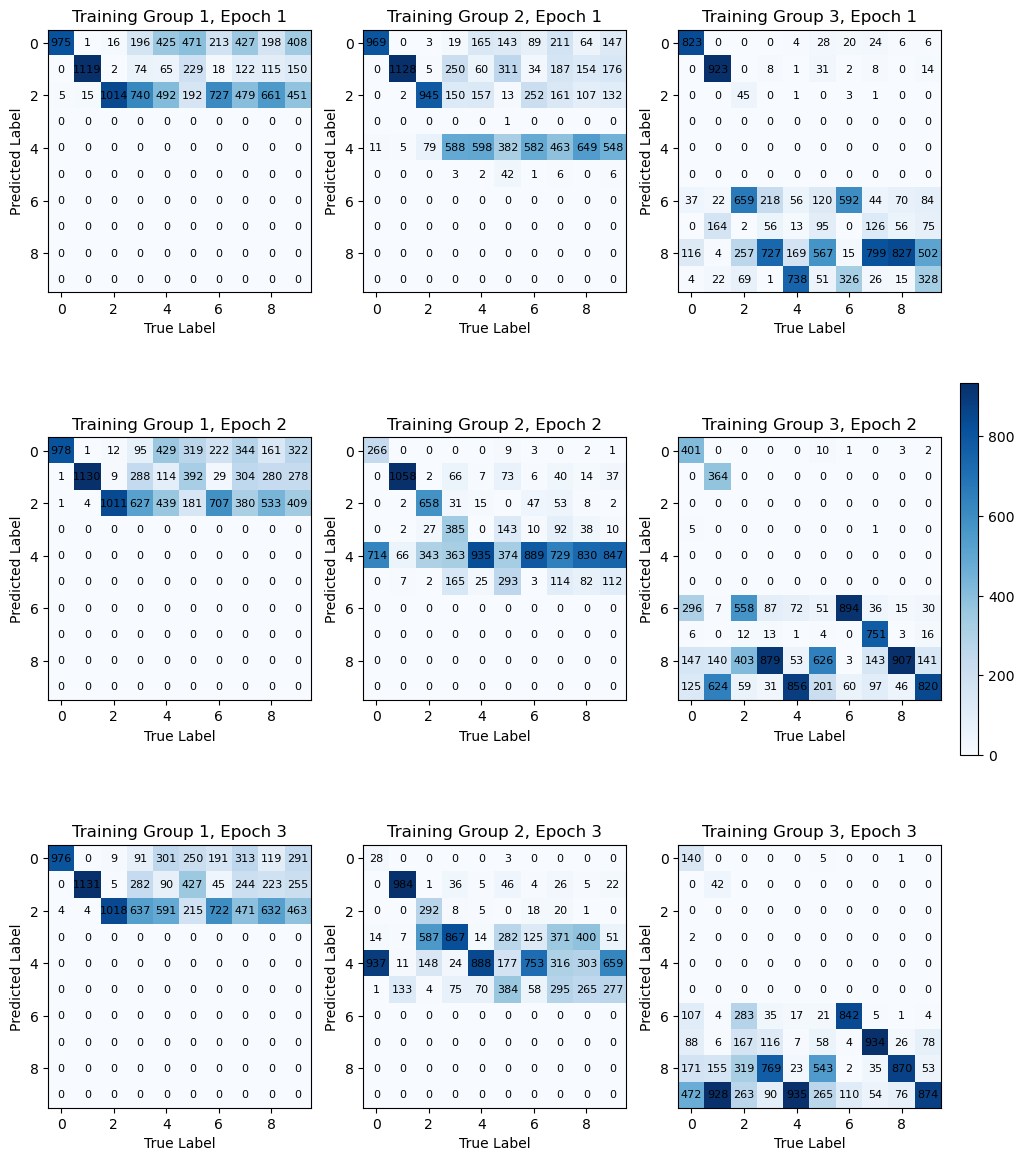

In [190]:
plot_cms(cm_group_set)

### PCA Analyses of Penultimate Layer

In [131]:
μ_cgm, σ_cgm = monte_carlo_cgm(dim_subspace=64, dim_space=64, n_samples=10_000, seed=42)

In [191]:
print(μ_cgm, σ_cgm)

0.10012973798232168 0.07482670359966154


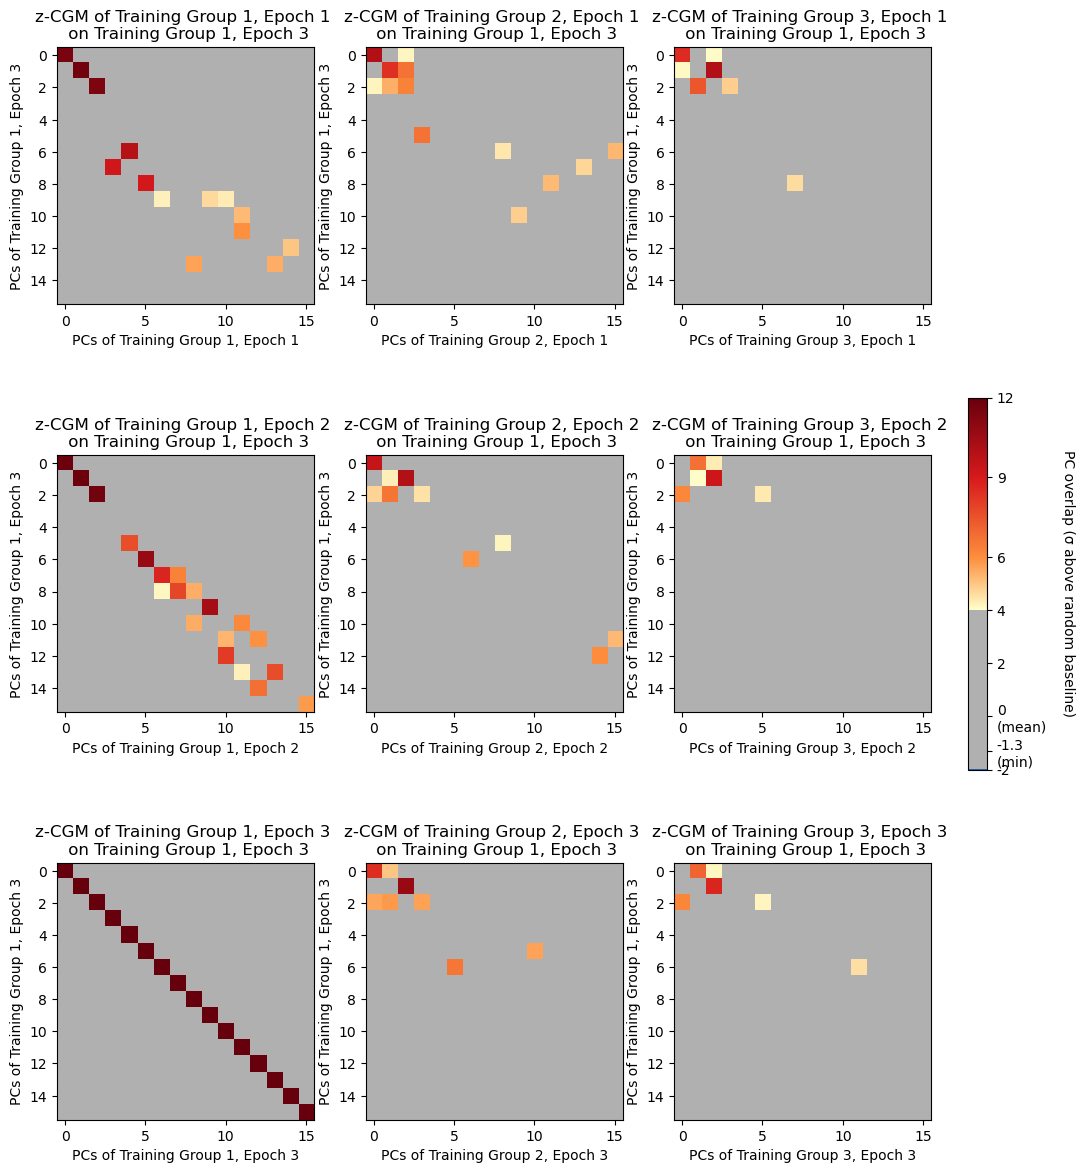

In [192]:
plot_cgms(pca_group_set, μ_cgm, σ_cgm, window=(0, num_old_pca_components), diagonalize=False)

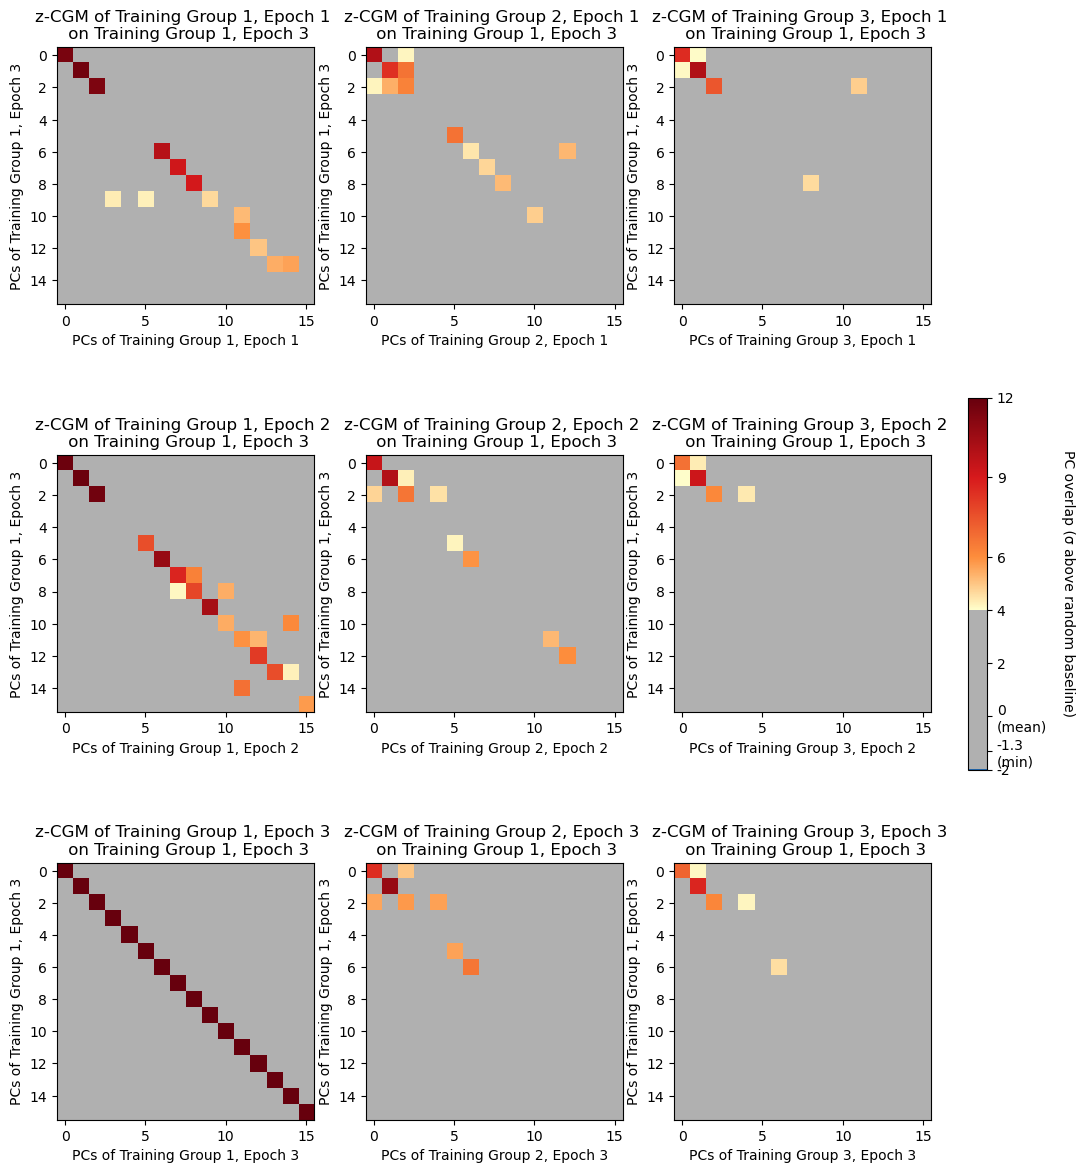

In [193]:
plot_cgms(pca_group_set, μ_cgm, σ_cgm, window=(0, num_old_pca_components), diagonalize=True)

### Control Plot

In [139]:
rng = np.random.default_rng(seed=42)
 
U = rng.standard_normal((64, 64)) 
V = rng.standard_normal((64, 64))        

U, _ = np.linalg.qr(U)                                                   
V, _ = np.linalg.qr(V)                                                   

cgm = np.abs(np.einsum("di, dj -> ij", U, V))        

c_cgm = (cgm - μ_cgm)/σ_cgm

In [140]:
U.shape, V.shape

((64, 64), (64, 64))

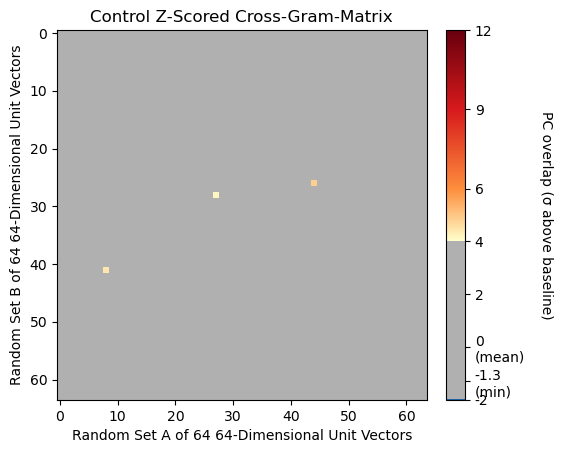

In [141]:
cgm_cmap, cgm_norm = make_cgm_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4    
                                        )
 
CGM_TICKS  = [-2, -1.3,         0,              2,        4,        6,        9,       12]
CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4', '6', '9', '12']

fig = plt.figure()

im = plt.imshow(c_cgm, cmap=cgm_cmap, norm=cgm_norm)
cbar = plt.colorbar(im, ticks=CGM_TICKS, fraction=0.05, pad=0.04)
cbar.ax.set_yticklabels(CGM_LABELS)
cbar.set_label("PC overlap (σ above baseline)", rotation=270, labelpad=20)

plt.title(f"Control Z-Scored Cross-Gram-Matrix")
plt.xlabel(f"Random Set A of 64 64-Dimensional Unit Vectors")
plt.ylabel(f"Random Set B of 64 64-Dimensional Unit Vectors")

plt.show()

### Computing Grassmannian Distance

In [ ]:
subspace_size = 32

In [ ]:
μ_gdist, σ_gdist = compute_random_baseline_gdist(dim_space=64, dim_subspace=subspace_size, n_samples=100_000, seed=42)

In [ ]:
print(μ_gdist, σ_gdist)

In [ ]:
gdist_set = []

In [ ]:
flattened_pca_set = np.reshape(pca_group_set, (-1))

for i in range(len(flattened_pca_set)-1):

    pca_A = flattened_pca_set[num_epochs-1].components_[:subspace_size] #(dim_subspace, dim_space)
    pca_B = flattened_pca_set[i].components_[:subspace_size] #(dim_subspace, dim_space)

    U = np.transpose(pca_A) #(dim_space, dim_subspace)
    V = np.transpose(pca_B) #(dim_space, dim_subspace)

    M = np.einsum("ij, ik->jk", U, V)
    sigma = np.linalg.svd(M, compute_uv=False)
    sigma = np.clip(sigma, -1, 1)

    pangles = np.arccos(sigma)

    gdist = np.linalg.norm(pangles)

    gdist_set.append(gdist)

In [ ]:
z_gdist_set = []

In [ ]:
for gdist in gdist_set:

    z_gdist = (gdist-μ_gdist)/σ_gdist

    z_gdist_set.append(z_gdist)

In [ ]:
plt.figure()

plt.plot([epoch for epoch in range(len(flattened_pca_set)-1)], z_gdist_set, marker = "s")
plt.title(f"Geodesic Distance Between Subspaces of First {subspace_size} PCs of Subsequent Epochs")
plt.xlabel(f"Epoch Number")
plt.ylabel(f"Geodesic Distance")
plt.grid(True)